# Unsupervised Clustering
Using unsupervised models to segment the user base. The assignment specifies Spectral Clustering or DBSCAN. We demonstrate both, with Spectral Clustering applied to the reduced dimensions.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, SpectralClustering

In [ ]:
df = pd.read_csv(r'C:\Users\nk090\Desktop\usl project\pca_features.csv', encoding='latin1')

In [3]:
# Method A: Spectral Clustering
# We use nearest_neighbors affinity for scalability on ~20k observations
print("Running Spectral Clustering...")
spectral = SpectralClustering(n_clusters=4, affinity="nearest_neighbors", random_state=42)
spectral_labels = spectral.fit_predict(df[["PC1", "PC2"]])
df["spectral_cluster"] = spectral_labels
print("Spectral clustering complete!")

Running Spectral Clustering...


c:\Python314\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Spectral clustering complete!


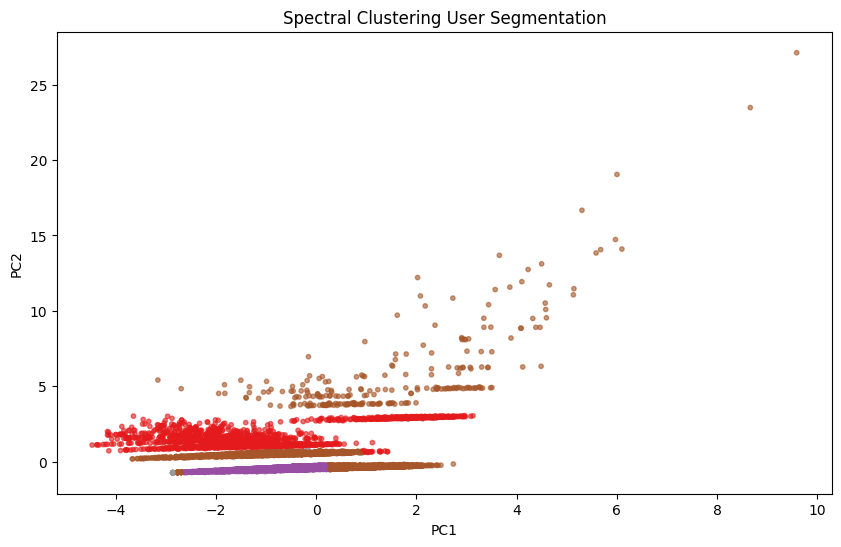

In [4]:
plt.figure(figsize=(10,6))
plt.scatter(df["PC1"], df["PC2"], c=df["spectral_cluster"], cmap="Set1", alpha=0.6, s=10)
plt.title("Spectral Clustering User Segmentation")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [5]:
# Method B: DBSCAN
print("Running DBSCAN...")
dbscan = DBSCAN(eps=0.2, min_samples=10)
dbscan_labels = dbscan.fit_predict(df[["PC1", "PC2"]])
df["dbscan_cluster"] = dbscan_labels
print("DBSCAN clustering complete! Unique clusters found (excl noise):", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))

Running DBSCAN...
DBSCAN clustering complete! Unique clusters found (excl noise): 11


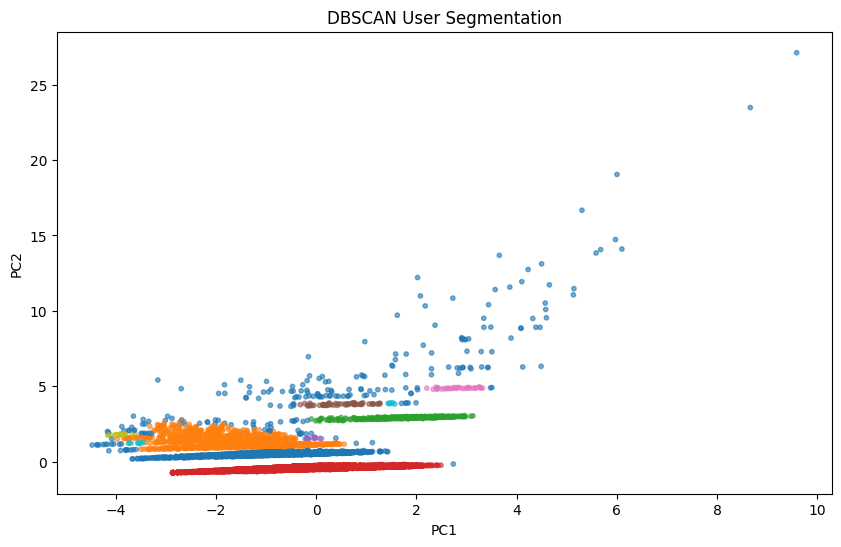

In [6]:
plt.figure(figsize=(10,6))
plt.scatter(df["PC1"], df["PC2"], c=df["dbscan_cluster"], cmap="tab10", alpha=0.6, s=10)
plt.title("DBSCAN User Segmentation")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [7]:
df.to_csv(r'C:\Users\nk090\Desktop\usl project\clustered_users.csv', index=False)
print("Saved clustered users to clustered_users.csv")

Saved clustered users to clustered_users.csv
